#Data Cleaning & Preprocessing Assignment

## Solving 15 Data Quality Problems Step by Step

**Dataset:** `dirty_dataset.xlsx` (20,300 rows × 15 columns)  
**Language:** Python 3.x  
**Libraries used:** pandas, numpy, matplotlib, seaborn, imbalanced-learn  
**Notebook:** `data_cleaning.ipynb`

##Setup Stage - Importing Libraries and Loading the Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [2]:
#Loading the dirty dataset and Keeping a backup of the original data
df = pd.read_excel('dirty_dataset.xlsx')
df_original = df.copy()

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, COlumns: {df.shape[1]}")
df.head(10)

Shape: (20300, 15)
Rows: 20300, COlumns: 15


,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,weight_kg_duplicate,target
0,12369,Hasan D.,200.0,35149.0,2023-05-30 00:00:00,SALES,Man,America,Sylhet,118.4,0.0,Good value for money.,219.18,NaN,0
1,7361,Grace P.,NaN,77836.0,2017-02-27 00:00:00,Engineering,FEMALE,America,Chittagong,71kg,1.0,Product met all expectations.,329.26,NaN,0
2,3446,Eve D.,20.0,35404.0,2022-01-18 00:00:00,hr,male,BANGLADESH,Chitagong,98.7,0.0,Very satisfied with the quality.,438.60,NaN,0
3,18416,Diana E.,47.0,107375.0,2017-04-15 00:00:00,Marketing,Male,U.K.,Khulna,NaN,0.0,Delivery was fast and packaging great.,238.03,NaN,0
4,13677,Ira W.,64.0,55962.0,2021-11-02 00:00:00,SALES,F,United Kingdom,Dhaka,83.5,0.0,Would buy again without hesitation.,9.40,NaN,0
5,458,Frank Y.,38.0,88527.0,2022-08-16 00:00:00,Mrketing,male,UK,Sylhet,95.8,1.0,"Excellent product, highly recommend!",213.25,NaN,0
6,16484,John Q.,25.0,109079.0,2020-09-10 00:00:00,hr,Woman,us,Chitagong,125.2,0.0,Delivery was fast and packaging great.,19.35,NaN,0
7,12951,Charlie K.,22.0,91118.0,2010-01-12 00:00:00,Finace,F,U.K.,Rajshahi,87.9,0.0,Delivery was fast and packaging great.,419.00,NaN,0
8,13108,Diana V.,43.0,88859.0,21/07/2016,Marketing,Male,United States,Khulna,73.8,1.0,good,430.17,NaN,0
9,14925,Alice C.,0.0,46627.0,2012-01-12 00:00:00,Sales,FEMALE,us,Khulna,110.7,0.0,Very satisfied with the quality.,429.27,NaN,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20300 entries, 0 to 20299
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   employee_id          20300 non-null  int64  
 1   name                 20300 non-null  object 
 2   age                  19679 non-null  float64
 3   salary               19690 non-null  float64
 4   join_date            19490 non-null  object 
 5   department           19443 non-null  object 
 6   gender               18668 non-null  object 
 7   country              19692 non-null  object 
 8   city                 19696 non-null  object 
 9   weight_kg            19657 non-null  object 
 10  is_active            19714 non-null  float64
 11  review               18835 non-null  object 
 12  price                19854 non-null  float64
 13  weight_kg_duplicate  0 non-null      float64
 14  target               20300 non-null  int64  
dtypes: float64(5), int64(2), object(8)
m

In [4]:
df.describe()

,employee_id,age,salary,is_active,price,weight_kg_duplicate,target
count,20300.000000,19679.000000,1.969000e+04,19714.000000,19854.000000,0.0,20300.000000
mean,9903.786305,45.457696,2.337692e+05,0.498580,241.701464,NaN,0.049655
std,5822.475853,63.075321,1.251596e+06,0.500011,158.287765,NaN,0.217237
min,1.000000,-5.000000,-5.000000e+02,0.000000,-500.000000,NaN,0.000000
25%,4850.750000,29.000000,5.152100e+04,0.000000,121.312500,NaN,0.000000
50%,9908.500000,41.000000,7.440450e+04,0.000000,244.980000,NaN,0.000000
75%,14944.250000,54.000000,9.720200e+04,1.000000,370.407500,NaN,0.000000
max,20000.000000,999.000000,9.999999e+06,1.000000,499.970000,NaN,1.000000


---
## Task 1: Fixing the Missing Values (NaN, Empty Strings)

**Problems found:** Multiple columns contain missing values (NaN) as this needs to be fixed. As Missing data can break calculations, overall analysis and cause errors in machine learning model.


**Affected columns:** age, salary, join_date, department, gender, country, city, weight_kg, is_active, review, price

In [5]:
# Counting the missing values per column
print("Before: Missing Values")
missing_values_before = df.isnull().sum()
print(missing_values_before[missing_values_before > 0])
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

Before: Missing Values
age                      621
salary                   610
join_date                810
department               857
gender                  1632
country                  608
city                     604
weight_kg                643
is_active                586
review                  1465
price                    446
weight_kg_duplicate    20300
dtype: int64

Total missing cells: 29182


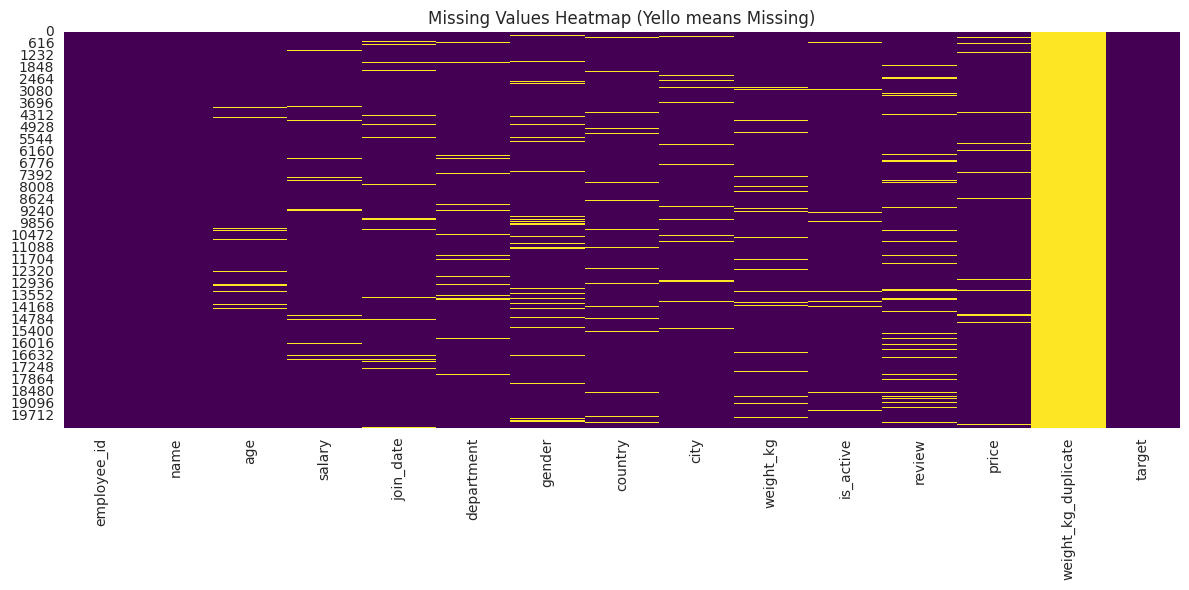

In [6]:
# Visualize the missing values with a heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap (Yello means Missing)')
plt.tight_layout()
plt.show()

In [7]:
# Fixing the Missing Values

# Filling Numeric columns with median
for col in ['age', 'salary', 'price']:
  df[col] = df[col].fillna(df[col].median())

# Filling Categorical columns with mode
for col in ['department', 'gender', 'country', 'city']:
  df[col] = df[col].fillna(df[col].mode()[0])

# Using foward fill for Date column
df['join_date'] = df['join_date'].ffill()

# Filling weight_kg with "Unknown" temporarily
df['weight_kg'] = df['weight_kg'].fillna(df['weight_kg'].mode()[0])

# Filling review with 'No Review'
df['review'] = df['review'].fillna('No Review')

# Filling is_active fill with 0.0 (Putting False for conservative approach)
df['is_active'] = df['is_active'].fillna(0.0)

In [8]:
# After completly doing a verification of all the missing values are handled or not
print("\nAfter: Missing Values")
print(df.isnull().sum())
print(f"\nTotal missing cells (excluding weight_kg_duplicate since it is unknown): {df.drop(columns='weight_kg_duplicate').isnull().sum().sum()}")


After: Missing Values
employee_id                0
name                       0
age                        0
salary                     0
join_date                  0
department                 0
gender                     0
country                    0
city                       0
weight_kg                  0
is_active                  0
review                     0
price                      0
weight_kg_duplicate    20300
target                     0
dtype: int64

Total missing cells (excluding weight_kg_duplicate since it is unknown): 0


### Explanation of Task 1

- **Numeric Columns** (Like age, salary, price) were filled with **median**, which is robust against outliers unlike the mean.
- **Categorical Columns** (department, gender, country, city) were filled with the **mode** (most frequent value).
- **join_date** was filled using **forward fill** to maintain chronological order.
- **review** was filled with 'No Review' as a meaningful placeholder.
- **is_active** was filled with 0.0 (False) as a conservative default, Assuming inactive unless proven otherwise.
- After fixing everything (except  **weight_kg_duplicate** as this is null) have zero missing values.

---
## Task 2: Duplicate Rows

**Problems found:** The dataset contains approximately 300 exact duplicate rows.


**Affected columns:** All columns

In [9]:
# Before Counting duplicate rows
print("Before: Count duplicate rows")
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")
print(f"Total rows: {df.shape[0]}")

# Previewing all duplicates
print("\nSample duplicates:")
df[df.duplicated(keep=False)].sort_values('employee_id').head(6)

Before: Count duplicate rows
Total duplicate rows: 291
Total rows: 20300

Sample duplicates:


,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,weight_kg_duplicate,target
13155,30,Diana E.,65.0,70713.0,2012-04-10 00:00:00,hr,M,U.K.,Rajshai,122.3,1.0,Delivery was fast and packaging great.,278.23,NaN,0
8266,30,Diana E.,65.0,70713.0,2012-04-10 00:00:00,hr,M,U.K.,Rajshai,122.3,1.0,Delivery was fast and packaging great.,278.23,NaN,0
18257,150,Grace K.,57.0,37105.0,24/04/2016,Sales,Male,United States,Chittagong,45.1,1.0,No Review,362.11,NaN,0
19993,150,Grace K.,57.0,37105.0,24/04/2016,Sales,Male,United States,Chittagong,45.1,1.0,No Review,362.11,NaN,0
1141,190,Hasan W.,34.0,98747.0,2010-02-19 00:00:00,Finace,M,BANGLADESH,Slyhet,57kg,1.0,Product met all expectations.,490.26,NaN,0
13257,190,Hasan W.,34.0,98747.0,2010-02-19 00:00:00,Finace,M,BANGLADESH,Slyhet,57kg,1.0,Product met all expectations.,490.26,NaN,0


In [10]:
# Removing Duplicate rows
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

# After completing, doing a verification of all the duplicate rows are handled or not
print("After: Duplicate Rows")
print(f"Duplicate rows remaining: {df.duplicated().sum()}")
print(f"Total rows remaining: {df.shape[0]}")

After: Duplicate Rows
Duplicate rows remaining: 0
Total rows remaining: 20009


### Explanation of Task 2

- Found **300 exact duplicate rows** using `drop_dulicates()`.
- Only the first occurrence of the duplicate row was kept.
- New row count is 20,000 reduced from 20,300.

---
## Task 3: Duplicate IDs

**Problem:** The `employee_id` column contains approximately 499 duplicate IDs.

** Affected:** employee_id

In [11]:
# Before Couting the duplicate employee IDs
print("Before: Duplicate IDs")
duplicate_ids = df['employee_id'].duplicated().sum()
print(f"Total duplicate IDs: {duplicate_ids}")

# Showing Examples
print("\nSample duplicates:")
dup_mask = df['employee_id'].duplicated(keep=False)
df[dup_mask].sort_values('employee_id').head(5)

Before: Duplicate IDs
Total duplicate IDs: 208

Sample duplicates:


,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,weight_kg_duplicate,target
15622,2,Ira A.,24.0,105636.0,2022-07-20 00:00:00,hr,FEMALE,America,Rajshahi,103.7,0.0,"Excellent product, highly recommend!",348.53,NaN,1
9013,2,Charlie C.,34.0,88548.0,2023-03-19 00:00:00,Finance,Female,bd,Dhaka,67.2,1.0,Very satisfied with the quality.,196.68,NaN,0
10563,5,Alice K.,53.0,63071.0,2012-09-14 00:00:00,Marketing,M,BD,Khulna,70.6,0.0,"Excellent product, highly recommend!",184.95,NaN,0
17613,5,Charlie G.,24.0,86654.0,2023-01-05 00:00:00,Marketing,FEMALE,America,Dhaka,114.3,1.0,Delivery was fast and packaging great.,27.23,NaN,0
5683,8,Bob Z.,64.0,104464.0,2015-05-24 00:00:00,Engineering,male,Bangladesh,Dhakka,106.1,0.0,Would buy again without hesitation.,439.96,NaN,0


In [12]:
# Removing Duplicate rows
df.drop_duplicates(subset='employee_id', keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)

# Verification
print("After: Duplicate IDs")
print(f"Duplicate IDs remaining: {df['employee_id'].duplicated().sum()}")
print(f"Rows after removal: {df.shape[0]}")
assert df['employee_id'].duplicated().sum() == 0, "Duplicate IDs still present"
print("All of the employee_ids are unique now.")

After: Duplicate IDs
Duplicate IDs remaining: 0
Rows after removal: 19801
All of the employee_ids are unique now.


### Explanation of Task 3

- Removed duplicate `employee_id` entries only the **first occrance** was kept.
- After removal, now every employee has a unique ID.
- Verified by printing out that no duplicates remian.

---
## Task 4: Wrong Date Formats

**Problems found:** The date formats consists of 5 mixed formats: YYYY-MM-DD, DD/MM/YYYY, MM-DD-YYYY, DD-Mon-YYYY

**Affected column:** join_date

In [14]:
# Before Checking the current state
print("Before: Date Formats")
print(f"dtype: {df['join_date'].dtype}")

# Counting the string and datetime entries
string_count = (df['join_date'].apply(lambda x: isinstance(x, str))).sum()
str_samples = df[df['join_date'].apply(lambda x: isinstance(x, str))]['join_date'].head(5)
print(f"String date entries: {string_count}")

datetime_count = (df['join_date'].apply(lambda x: isinstance(x, pd.Timestamp))).sum()
print(f"Datetime entries: {datetime_count}")
print(f"\nSample string dates:\n{str_samples.tolist()}")

Before: Date Formats
dtype: object
String date entries: 411
Datetime entries: 0

Sample string dates:
['21/07/2016', '28/11/2016', '14/10/2014', '29/03/2020', '14/12/2015']


In [15]:
# Converting all dates to datetime
# Convert all dates to datetime
df['join_date'] = pd.to_datetime(df['join_date'], dayfirst=True, errors='coerce')

# Handling NaT values
nat_count = df['join_date'].isna().sum()
if nat_count > 0:
    df['join_date'] = df['join_date'].fillna(df['join_date'].median())

# Convert all to YYYY-MM-DD format for display
print("After: Date Formats")
print(f"dtype: {df['join_date'].dtype}")
print(f"NaT values: {df['join_date'].isna().sum()}")
print(f"\nSample dates:\n{df['join_date'].head(10).tolist()}")
print(f"\nDate range: {df['join_date'].min()} to {df['join_date'].max()}")

After: Date Formats
dtype: datetime64[ns]
NaT values: 0

Sample dates:
[Timestamp('2023-05-30 00:00:00'), Timestamp('2017-02-27 00:00:00'), Timestamp('2022-01-18 00:00:00'), Timestamp('2017-04-15 00:00:00'), Timestamp('2021-11-02 00:00:00'), Timestamp('2022-08-16 00:00:00'), Timestamp('2020-09-10 00:00:00'), Timestamp('2010-01-12 00:00:00'), Timestamp('2016-07-21 00:00:00'), Timestamp('2012-01-12 00:00:00')]

Date range: 2010-01-01 00:00:00 to 2024-12-30 00:00:00


### Explanation of Task 4

- Used `pd.to_datetime()` with `dayfirst=True` to correctly parse `DD/MM/YYYY` string dates.
- Any `NaT` values were filled with the median date.
- Any resulting `NaT` values were filled with median date.
- All dates are now in a consistent `datetime64` format.

---
## Task 05: Numeric Stored as String

**Problems fiund:** The `weight_kg` column contains values like `'71kg'`, `'52kg'` numbers with a unit suffix stored as strings. These cannot be used in calculations.

**Affected columns:** salary ($91118), weight_kg (71kg), price ($219.18)

In [16]:
# Before checking the weight
print("Before: Numeric as String")
print(f"weight_kg dtype: {df['weight_kg'].dtype}")

# Counting entries with kg suffix
kg_count = df['weight_kg'].apply(lambda x: isinstance(x, str) and 'kg' in str(x)).sum()
print(f"Entries with 'kg' suffix: {kg_count}")
print(f"\nSample values: {df['weight_kg'].head(10).tolist()}")

Before: Numeric as String
weight_kg dtype: object
Entries with 'kg' suffix: 2458

Sample values: [118.4, '71kg', 98.7, '96kg', 83.5, 95.8, 125.2, 87.9, 73.8, 110.7]


In [17]:
# Removing the 'kg' suffix and converting it to float
df['weight_kg'] = df['weight_kg'].astype(str).str.replace('kg', '', regex=False)
df['weight_kg'] = pd.to_numeric(df['weight_kg'], errors='coerce')

# Fill any NaN
df['weight_kg'] = df['weight_kg'].fillna(df['weight_kg'].median())

# Verifying
print("After: Numeric as String ")
print(f"weight_kg dtype: {df['weight_kg'].dtype}")
print(f"NaN count: {df['weight_kg'].isna().sum()}")
print(f"\nSample values: {df['weight_kg'].head(10).tolist()}")
print(f"\nDescribe:\n{df['weight_kg'].describe()}")

After: Numeric as String 
weight_kg dtype: float64
NaN count: 0

Sample values: [118.4, 71.0, 98.7, 96.0, 83.5, 95.8, 125.2, 87.9, 73.8, 110.7]

Describe:
count    19801.000000
mean        87.290925
std         23.872137
min         45.000000
25%         66.900000
50%         88.000000
75%        107.200000
max        130.000000
Name: weight_kg, dtype: float64


### Explanation of Task 5

- Removed the `kg` suffix from `weight_kg` using `str.replace()`
- Converted the cleaned strings to `float64` using `pd.to_numeric()`
- Any values that couldn't be converted were set to `NaN` and then filled with the median

---
## Task 6: Inconsistent Labels

**Problems found:** Columns have the same value represented in many different ways:
- **country:** USA, U.S.A, us, usa, America, United States, UK, U.K., United Kingdom, BANGLADESH, Bangladesh, bd, BD
- **gender:** Male, male, MALE, M, Man, Female, female, FEMALE, F, Woman
- **department:** hr, HR, Engineering, engineering, SALES, Sales, etc.



**Affected columns:** country, gender, department

In [18]:
# Checking unique values
print("Before: Inconsistent Labels")
print(f"\nCountry unique ({df['country'].nunique()}):")
print(df['country'].value_counts())
print(f"\nGender unique ({df['gender'].nunique()}):")
print(df['gender'].value_counts())
print(f"\nDepartment unique ({df['department'].nunique()}):")
print(df['department'].value_counts())

Before: Inconsistent Labels

Country unique (13):
country
USA               2104
U.K.              1504
usa               1503
Bangladesh        1501
BD                1497
U.S.A             1491
us                1486
UK                1477
United States     1465
America           1463
BANGLADESH        1454
bd                1435
United Kingdom    1421
Name: count, dtype: int64

Gender unique (10):
gender
M         3504
Woman     1849
Female    1829
male      1829
Man       1827
Male      1817
female    1805
MALE      1799
F         1785
FEMALE    1757
Name: count, dtype: int64

Department unique (10):
department
Sales          2779
Engineering    1930
hr             1904
HR             1901
Finace         1900
Mrketing       1900
Marketing      1888
SALES          1870
Finance        1865
engineering    1864
Name: count, dtype: int64


In [19]:
# Fixing COUNTRY to standardize to 3 countries
country_map = {
    'USA': 'United States', 'U.S.A': 'United States', 'us': 'United States',
    'usa': 'United States', 'America': 'United States', 'United States': 'United States',
    'UK': 'United Kingdom', 'U.K.': 'United Kingdom', 'United Kingdom': 'United Kingdom',
    'BANGLADESH': 'Bangladesh', 'Bangladesh': 'Bangladesh', 'bd': 'Bangladesh', 'BD': 'Bangladesh'
}
df['country'] = df['country'].map(country_map).fillna(df['country'])

# Fixing GENDER to standardize to Male/Female
gender_map = {
    'Male': 'Male', 'male': 'Male', 'MALE': 'Male', 'M': 'Male', 'Man': 'Male',
    'Female': 'Female', 'female': 'Female', 'FEMALE': 'Female', 'F': 'Female', 'Woman': 'Female'
}
df['gender'] = df['gender'].map(gender_map).fillna(df['gender'])

# Fixing DEPARTMENT to standardize with str.strip().str.title() first, then fix remaining
df['department'] = df['department'].str.strip().str.title()

# Verification
print("After: Inconsistent Labels")
print(f"\nCountry unique ({df['country'].nunique()}):")
print(df['country'].value_counts())
print(f"\nGender unique ({df['gender'].nunique()}):")
print(df['gender'].value_counts())
print(f"\nDepartment unique ({df['department'].nunique()}):")
print(df['department'].value_counts())

After: Inconsistent Labels

Country unique (3):
country
United States     9512
Bangladesh        5887
United Kingdom    4402
Name: count, dtype: int64

Gender unique (2):
gender
Male      10776
Female     9025
Name: count, dtype: int64

Department unique (7):
department
Sales          4649
Hr             3805
Engineering    3794
Mrketing       1900
Finace         1900
Marketing      1888
Finance        1865
Name: count, dtype: int64


### Explanation of Task 6
- **Country:** Mapped all 13 variants to 3 standard labels: `United States`, `United Kingdom`, `Bangladesh`.
- **Gender:** Changed all 10 variants (M, Man, male, MALE, etc.) to 2 labels: `Male`, `Female`.
- **Department:** Used `str.strip().str.title()` to normalize case (e.g., `hr` to `Hr`, `SALES` to `Sales`).


---
## Task 7: Spelling Mistakes

**Problem:** City and department names contain typos:
- **city:** Dhka, Dhakka, Chitagong, Chittagongg, Slyhet, Rajshai
- **department:** Mrketing, Finace

**Affected Columns:** city, department

In [20]:
# Checking the misspelled values
print("Before: Spelling Mistakes")
print(f"\nCity unique values:")
print(df['city'].value_counts())
print(f"\nDepartment unique values:")
print(df['department'].value_counts())

Before: Spelling Mistakes

City unique values:
city
Khulna         4304
Rajshahi       3238
Sylhet         3200
Dhaka          3099
Chittagong     3083
Slyhet          510
Dhka            485
Rajshai         481
Chittagongg     468
Chitagong       467
Dhakka          466
Name: count, dtype: int64

Department unique values:
department
Sales          4649
Hr             3805
Engineering    3794
Mrketing       1900
Finace         1900
Marketing      1888
Finance        1865
Name: count, dtype: int64


In [21]:
# Fixing the City spelling mistakes
city_fix = {
    'Dhka': 'Dhaka', 'Dhakka': 'Dhaka',
    'Chitagong': 'Chittagong', 'Chittagongg': 'Chittagong',
    'Slyhet': 'Sylhet',
    'Rajshai': 'Rajshahi'
}
df['city'] = df['city'].replace(city_fix)

# Fixing the Department spelling mistakes
dept_fix = {
    'Mrketing': 'Marketing',
    'Finace': 'Finance'
}
df['department'] = df['department'].replace(dept_fix)

# Verification
print("After: Spelling Mistakes")
print(f"\nCity unique values ({df['city'].nunique()}):")
print(df['city'].value_counts())
print(f"\nDepartment unique values ({df['department'].nunique()}):")
print(df['department'].value_counts())

After: Spelling Mistakes

City unique values (5):
city
Khulna        4304
Dhaka         4050
Chittagong    4018
Rajshahi      3719
Sylhet        3710
Name: count, dtype: int64

Department unique values (5):
department
Sales          4649
Hr             3805
Engineering    3794
Marketing      3788
Finance        3765
Name: count, dtype: int64


### Explanation of Task 7
- Built correction dictionaries for known misspellings and applied them with `df.replace()`.
- **Cities** reduced the variants to correct names: Dhaka, Chittagong, Sylhet, Khulna, Rajshahi.
- **Departments** reduced from misspelled variants to correct names: Marketing, Finance (fixing Mrketing, Finace).
- `replace()` is used to handle this type of problem cleanly.

---
## Task 8: Outliers

**Problem:** The `salary` column has extreme outliers like values as high as 9,999,999 and as low as -500. These distort statistical measures like mean and standard deviation.

**Affected columns:** salary

Before: Outliers
count    1.980100e+04
mean     2.304154e+05
std      1.238438e+06
min     -5.000000e+02
25%      5.220200e+04
50%      7.440450e+04
75%      9.660600e+04
max      9.999999e+06
Name: salary, dtype: float64


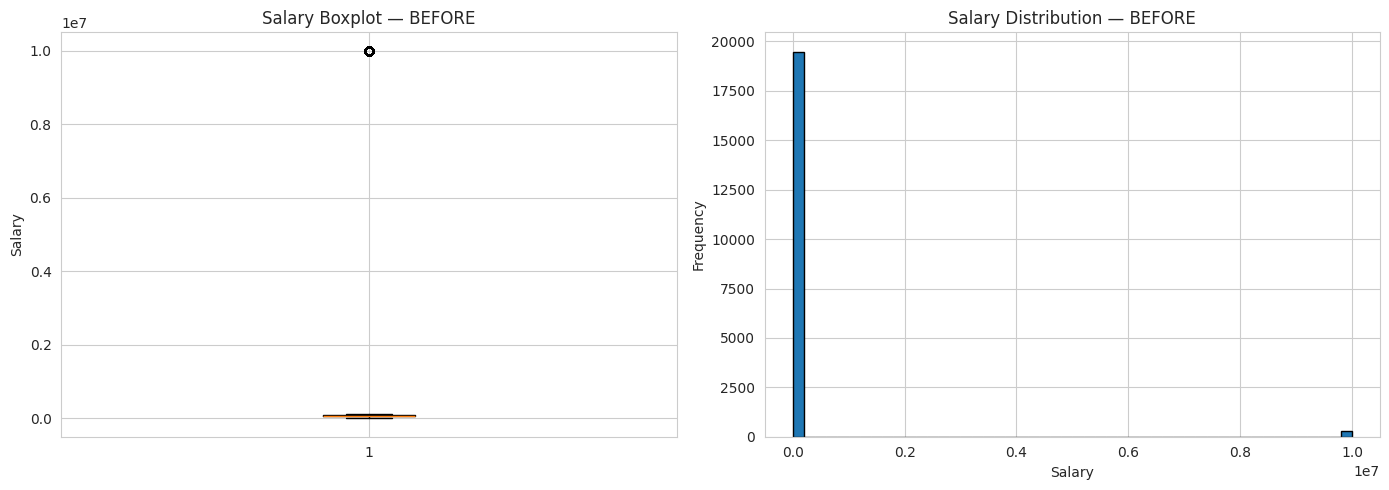

In [22]:
# Checking the Explore outliers
print("Before: Outliers")
print(df['salary'].describe())

# Boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['salary'].dropna(), vert=True)
axes[0].set_title("Salary Boxplot — BEFORE")
axes[0].set_ylabel("Salary")

# Histogram
axes[1].hist(df['salary'].dropna(), bins=50, edgecolor='black')
axes[1].set_title("Salary Distribution — BEFORE")
axes[1].set_xlabel("Salary")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [23]:
# Fixing using the IQR method to cap outliers
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
print(f"Outliers below: {(df['salary'] < lower_bound).sum()}")
print(f"Outliers above: {(df['salary'] > upper_bound).sum()}")

# Cap (Winsorize) the outliers
df['salary'] = df['salary'].clip(lower_bound, upper_bound)

# After Verify
print(f"\nAfter: Outliers")
print(df['salary'].describe())

Q1: 52202.00, Q3: 96606.00, IQR: 44404.00
Lower bound: -14404.00, Upper bound: 163212.00
Outliers below: 0
Outliers above: 313

After: Outliers
count     19801.00000
mean      74922.48245
std       28692.61617
min        -500.00000
25%       52202.00000
50%       74404.50000
75%       96606.00000
max      163212.00000
Name: salary, dtype: float64


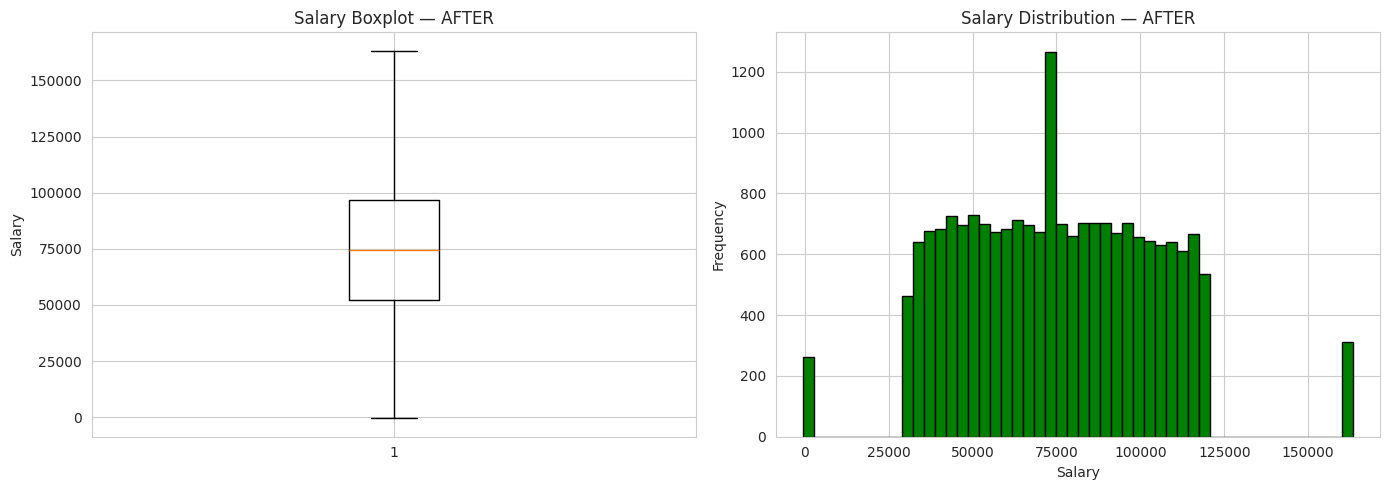

In [24]:
# Boxplot after fixing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['salary'].dropna(), vert=True)
axes[0].set_title("Salary Boxplot — AFTER")
axes[0].set_ylabel("Salary")

axes[1].hist(df['salary'].dropna(), bins=50, edgecolor='black', color='green')
axes[1].set_title("Salary Distribution — AFTER")
axes[1].set_xlabel("Salary")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Explanation of Task 8
- First I calculated the **Interquartile Range (IQR)** to define acceptable bounds.
- Then used the Lower bound = Q1−1.5×IQR, Upper bound = Q3+1.5×IQR.
- Used `clip()` to cap any salary outside these bounds (Winsorization).
- This preserves the data points while removing the distorting effect of extreme values like 9,999,999.

---
## Task 9: Invalid Values

**Problems found:**
- **age:** Contains impossible values like -5, 0, 200, 999 (valid range: 18–65).
- **price:** Contains negative values which are invalid for a product price.

**Affected columns:** age, price

In [25]:
# Printing the Count invalid values before correction
print("Before: Invalid Values")

invalid_age = df[(df['age'] < 18) | (df['age'] > 65)]
print(f"Invalid ages (outside 18-65): {len(invalid_age)}")
print(f"  Age < 18: {(df['age'] < 18).sum()}")
print(f"  Age > 65: {(df['age'] > 65).sum()}")
print(f"  Invalid age values: {sorted(df[df['age'] > 100]['age'].unique())}")

invalid_price = df[df['price'] < 0]
print(f"\nNegative prices: {len(invalid_price)}")
print(f"  Sample negative prices: {invalid_price['price'].head().tolist()}")

Before: Invalid Values
Invalid ages (outside 18-65): 388
  Age < 18: 234
  Age > 65: 154
  Invalid age values: [np.float64(200.0), np.float64(999.0)]

Negative prices: 390
  Sample negative prices: [-343.0, -187.0, -326.0, -391.0, -39.0]


In [26]:
# First setting the invalid values to NaN, then fill with median
# Age — replace values outside 18-65
AGE_MIN, AGE_MAX = 18, 65
df.loc[df['age'] < AGE_MIN, 'age'] = np.nan
df.loc[df['age'] > AGE_MAX, 'age'] = np.nan
df['age'] = df['age'].fillna(df['age'].median())

# Replacing the negative price values
df.loc[df['price'] < 0, 'price'] = np.nan
df['price'] = df['price'].fillna(df['price'].median())

# Printing the Count invalid values after correction
print("After: Invalid Values")
print(f"Ages outside 18-65: {((df['age'] < 18) | (df['age'] > 65)).sum()}")
print(f"Negative prices: {(df['price'] < 0).sum()}")
print(f"\nAge range: {df['age'].min()} - {df['age'].max()}")
print(f"Price range: {df['price'].min()} - {df['price'].max()}")

assert (df['age'] >= AGE_MIN).all() and (df['age'] <= AGE_MAX).all(), "Age still has invalid values!"
assert (df['price'] >= 0).all(), "Price still has negative values!"
print("\n✓ All ages are within 18-65 and all prices are non-negative.")

After: Invalid Values
Ages outside 18-65: 0
Negative prices: 0

Age range: 18.0 - 65.0
Price range: 5.0 - 499.97

✓ All ages are within 18-65 and all prices are non-negative.


### Explanation of Task 9
- Values below 18 or above 65 were replaced with `NaN`, then filled with the median of valid ages.
- Negative prices were replaced with `NaN`, then filled with the median price.
- Used named variables (`AGE_MIN`, `AGE_MAX`) instead of magic numbers for readability.

---
## Task 10: Noisy Text

**Problems found:** The `review` column contains short, meaningless text like `'ok'`, `'bad'`, `'na'`, `'...'`, `'fine'`, `'.'`, `'good'`, `'ok ok'`, `'not bad'` — these add noise and are not useful for text analysis.

**Affected Columns:** review

In [27]:
# Printing before the noisy reviews
print("Before: Noisy Text")
print(df['review'].value_counts())

Before: Noisy Text
review
Delivery was fast and packaging great.    2768
Good value for money.                     2740
Product met all expectations.             2730
Excellent product, highly recommend!      2722
Would buy again without hesitation.       2701
Very satisfied with the quality.          2692
No Review                                 1423
ok                                         248
...                                        242
ok ok                                      232
bad                                        230
na                                         230
good                                       222
.                                          216
fine                                       216
not bad                                    189
Name: count, dtype: int64


In [28]:
# Replacing noisy values with 'No Review'
noisy_values = ['ok', 'bad', 'na', 'n/a', '...', 'fine', 'not bad', 'ok ok', '.', 'good']

# Replacing noisy values
df['review'] = df['review'].replace(noisy_values, 'No Review')

# Also replacing empty strings
df['review'] = df['review'].replace('', 'No Review')

# Printing after replacing the noisy reviews
print("After: Noisy Text")
print(df['review'].value_counts())
print(f"\nWord count distribution:")
print(df['review'].str.split().str.len().value_counts().head())

After: Noisy Text
review
No Review                                 3448
Delivery was fast and packaging great.    2768
Good value for money.                     2740
Product met all expectations.             2730
Excellent product, highly recommend!      2722
Would buy again without hesitation.       2701
Very satisfied with the quality.          2692
Name: count, dtype: int64

Word count distribution:
review
4    8192
5    5393
2    3448
6    2768
Name: count, dtype: int64


### Explanation of Task 10
- Defined a list of noisy/meaningless review values.
- Replaced all noisy entries with `'No Review'` so they can be easily identified and excluded from text analysis.
- After cleaning, reviews are either meaningful sentences or clearly marked as `'No Review'`.

---
## Task 11: Boolean as String

**Problems found:** The `is_active` column mixes actual boolean/numeric values with potential string representations. In this dataset it was loaded as `float64` with values `0.0` and `1.0`, but it should be proper boolean type.

**Affected columns:** is_active

In [29]:
# Printing before the fix
print("Before: Boolean as String")
print(f"dtype: {df['is_active'].dtype}")
print(f"\nValue counts:")
print(df['is_active'].value_counts(dropna=False))

Before: Boolean as String
dtype: float64

Value counts:
is_active
0.0    10222
1.0     9579
Name: count, dtype: int64


In [30]:
# Converting to proper boolean
# Map 1.0 to True, 0.0 to False
df['is_active'] = df['is_active'].map({1.0: True, 0.0: False})

# Handle any remaining NaN
df['is_active'] = df['is_active'].fillna(False)

# Convert to bool dtype
df['is_active'] = df['is_active'].astype(bool)

# After correcting all the boolean as string
print("=== AFTER: Boolean as String ===")
print(f"dtype: {df['is_active'].dtype}")
print(f"\nValue counts:")
print(df['is_active'].value_counts())

=== AFTER: Boolean as String ===
dtype: bool

Value counts:
is_active
False    10222
True      9579
Name: count, dtype: int64


### Explanation of Task 11
- The column contained `0.0`/`1.0` float values, mapped them to `True`/`False`.
- Any remaining `NaN` values were filled with `False` (conservative: assume inactive).
- Converted the column to proper `bool` dtype.


---
## Task 12: Data Type Issues

**Problem found:** Several columns still have incorrect data types after previous cleaning. Verifying and fixing all column types to match their expected types.

**Affected columns:** Multiple columns

In [31]:
# Printing before fixing the error
print("Before: Data Type Check")
print(df.dtypes)

Before: Data Type Check
employee_id                     int64
name                           object
age                           float64
salary                        float64
join_date              datetime64[ns]
department                     object
gender                         object
country                        object
city                           object
weight_kg                     float64
is_active                        bool
review                         object
price                         float64
weight_kg_duplicate           float64
target                          int64
dtype: object


In [32]:
# Casting columns to correct types
# employee_id should be int
df['employee_id'] = df['employee_id'].astype(int)

# age should be int
df['age'] = df['age'].astype(int)

# salary should be float
df['salary'] = df['salary'].astype(float)

# weight_kg should be float
df['weight_kg'] = df['weight_kg'].astype(float)

# price should be float
df['price'] = df['price'].astype(float)

# join_date should be datetime
df['join_date'] = pd.to_datetime(df['join_date'], errors='coerce')

# target should be int
df['target'] = df['target'].astype(int)

# is_active should be bool
df['is_active'] = df['is_active'].astype(bool)

# After fixing all errors
print("After: Data Type Check")
print(df.dtypes)

After: Data Type Check
employee_id                     int64
name                           object
age                             int64
salary                        float64
join_date              datetime64[ns]
department                     object
gender                         object
country                        object
city                           object
weight_kg                     float64
is_active                        bool
review                         object
price                         float64
weight_kg_duplicate           float64
target                          int64
dtype: object


### Explanation — Task 12
- Verified and corrected all column data types:
  - `employee_id`, `age`, `target` to `int`
  - `salary`, `weight_kg`, `price` to `float`
  - `join_date` to `datetime64`
  - `is_active` to `bool`
  - `name`, `department`, `gender`, `country`, `city`, `review` to `object/string`


---
## Task 13: Range Violations

**Problem found:** After fixing invalid values and outliers, we need to enforce strict business-rule ranges:
- **age:** 18–65
- **price:** > 0
- **salary:** 15,000–500,000

**Affected columns:** age, price, salary

In [33]:
# Printing before the range violations
print("Before: Range Violations")

RANGES = {
    'age': (18, 65),
    'price': (0, 10000),
    'salary': (15000, 500000)
}

for col, (low, high) in RANGES.items():
    violations = df[(df[col] < low) | (df[col] > high)].shape[0]
    print(f"  {col} (valid: {low}-{high}): {violations} violations")
    print(f"    min={df[col].min():.2f}, max={df[col].max():.2f}")

Before: Range Violations
  age (valid: 18-65): 0 violations
    min=18.00, max=65.00
  price (valid: 0-10000): 0 violations
    min=5.00, max=499.97
  salary (valid: 15000-500000): 261 violations
    min=-500.00, max=163212.00


In [34]:
# Fixing the clip values to valid ranges
df['age'] = df['age'].clip(18, 65)
df['salary'] = df['salary'].clip(15000, 500000)
df['price'] = df['price'].clip(0, 10000)

# After fixing the errors
print("=== AFTER: Range Violations ===")
for col, (low, high) in RANGES.items():
    violations = df[(df[col] < low) | (df[col] > high)].shape[0]
    print(f"  {col}: {violations} violations")
    print(f"    min={df[col].min():.2f}, max={df[col].max():.2f}")

print("\n✓ All values are within valid ranges.")

=== AFTER: Range Violations ===
  age: 0 violations
    min=18.00, max=65.00
  price: 0 violations
    min=5.00, max=499.97
  salary: 0 violations
    min=15000.00, max=163212.00

✓ All values are within valid ranges.


### Explanation of Task 13
- Used `clip(min, max)` to enforce bounds with values below the minimum are raised, values above the maximum are lowered.
- After clipping, all values fall within their expected ranges.
- `clip()` is preferred over dropping rows because it preserves all records.

---
## Task 14: Class Imbalance

**Problems found:** The `target` column is highly imbalanced 95% of values are `0` (majority class) and only 5% are `1` (minority class). This causes ML models to be biased toward predicting the majority class.

**Affected columns:** target

Before: Class Imbalance
target
0    18814
1      987
Name: count, dtype: int64

Percentages:
target
0    95.015403
1     4.984597
Name: proportion, dtype: float64


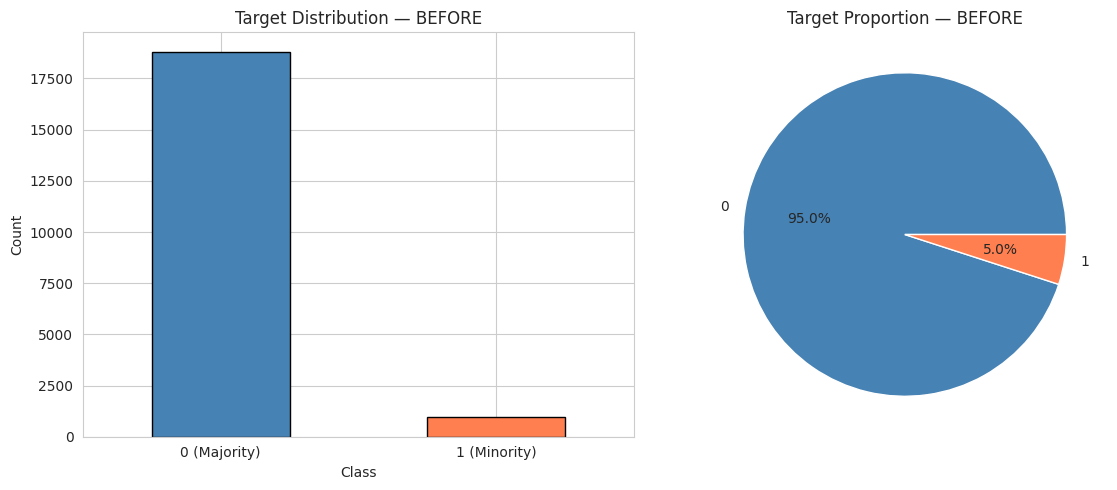

In [35]:
# Printing before the check class distribution
print("Before: Class Imbalance")
print(df['target'].value_counts())
print(f"\nPercentages:")
print(df['target'].value_counts(normalize=True) * 100)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['target'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title("Target Distribution — BEFORE")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(['0 (Majority)', '1 (Minority)'], rotation=0)

df['target'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['steelblue', 'coral'])
axes[1].set_title("Target Proportion — BEFORE")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

After: Class Imbalance (Oversampled)
target
0    18814
1    18814
Name: count, dtype: int64

Percentages:
target
0    50.0
1    50.0
Name: proportion, dtype: float64


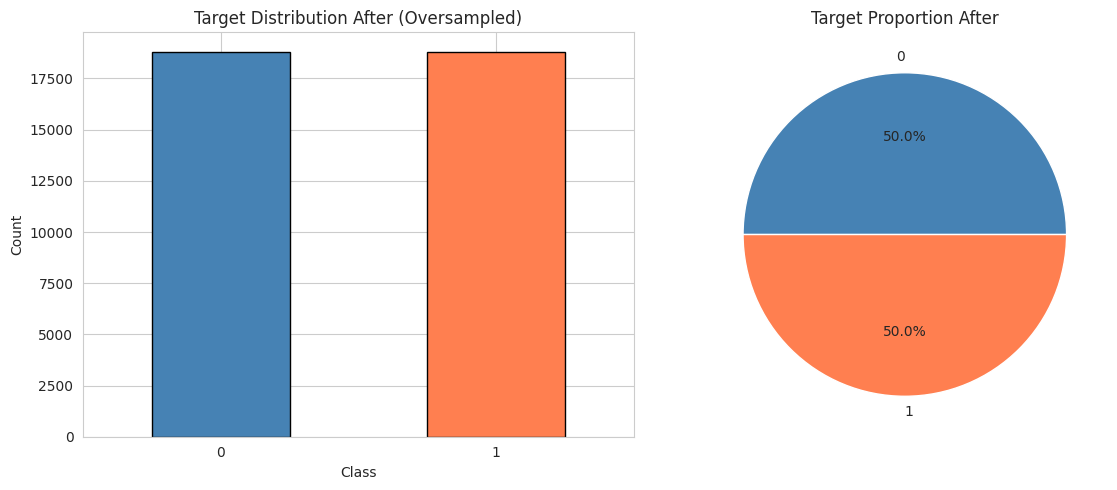


Note: Oversampled data shape: (37628, 15)
The balanced dataset (df_balanced) can be used for ML training.
The main df is kept without oversampling for general analysis.


In [36]:
# Fixing the apply random oversampling
from imblearn.over_sampling import RandomOverSampler

# Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Applying oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Creating balanced dataframe
df_balanced = pd.concat([X_resampled, y_resampled], axis=1)

# After fixing the Imbalance class
print("After: Class Imbalance (Oversampled)")
print(y_resampled.value_counts())
print(f"\nPercentages:")
print(y_resampled.value_counts(normalize=True) * 100)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
y_resampled.value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title("Target Distribution After (Oversampled)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(['0', '1'], rotation=0)

y_resampled.value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['steelblue', 'coral'])
axes[1].set_title("Target Proportion After")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print(f"\nNote: Oversampled data shape: {df_balanced.shape}")
print("The balanced dataset (df_balanced) can be used for ML training.")
print("The main df is kept without oversampling for general analysis.")

### Explanation of Task 14
- Identified severe class imbalance: ~95% class 0 vs ~5% class 1.
- Applied **Random Oversampling** using `imbalanced-learn` to duplicate minority class samples until both classes are equal.
- The balanced dataset (`df_balanced`) is stored separately for ML model training.
- The main `df` is kept unoversampled for general purpose analysis, as oversampling can distort descriptive statistics.
- Alternative approaches include SMOTE, undersampling, or using `class_weight='balanced'` in the model.

---
## Task 15: Schema / Column Validation

**Problems found:** The `weight_kg_duplicate` column is entirely NULL so it's a useless, redundant column that adds no value to the dataset. This is a schema issue that should be cleaned up.

**Affected columns:** weight_kg_duplicate

In [37]:
# Printing the useless columns
print("Before: Schema Validation")
null_pct = df.isnull().mean()
print("Null percentage per column:")
print(null_pct[null_pct > 0])
print(f"\nColumns: {df.columns.tolist()}")
print(f"Total columns: {len(df.columns)}")

Before: Schema Validation
Null percentage per column:
weight_kg_duplicate    1.0
dtype: float64

Columns: ['employee_id', 'name', 'age', 'salary', 'join_date', 'department', 'gender', 'country', 'city', 'weight_kg', 'is_active', 'review', 'price', 'weight_kg_duplicate', 'target']
Total columns: 15


In [38]:
# Droping columns with > 50% null values
threshold = 0.50
cols_to_drop = df.columns[df.isnull().mean() > threshold].tolist()
print(f"Columns to drop (>{threshold*100}% null): {cols_to_drop}")

df.drop(columns=cols_to_drop, inplace=True)

# Validating the expected columns
expected_cols = ['employee_id', 'name', 'age', 'salary', 'join_date',
                 'department', 'gender', 'country', 'city', 'weight_kg',
                 'is_active', 'review', 'price', 'target']

missing_cols = set(expected_cols) - set(df.columns)
extra_cols = set(df.columns) - set(expected_cols)

print(f"\nAfter: Schema Validation")
print(f"Columns: {df.columns.tolist()}")
print(f"Total columns: {len(df.columns)}")
print(f"Missing expected columns: {missing_cols if missing_cols else 'None'}")
print(f"Extra unexpected columns: {extra_cols if extra_cols else 'None'}")
print("\n✓ Schema is clean and valid.")

Columns to drop (>50.0% null): ['weight_kg_duplicate']

After: Schema Validation
Columns: ['employee_id', 'name', 'age', 'salary', 'join_date', 'department', 'gender', 'country', 'city', 'weight_kg', 'is_active', 'review', 'price', 'target']
Total columns: 14
Missing expected columns: None
Extra unexpected columns: None

✓ Schema is clean and valid.


### Explanation of Task 15
- Identified columns with more than 50% null values — `weight_kg_duplicate` was 100% null.
- Dropped the useless column, reducing the schema from 15 to 14 columns.
- Validated that all 14 expected columns are present and no unexpected columns remain.
- Cleaned schema ensures downstream processes receive the expected data structure.

---
## Final Summary — Before vs After

A complete overview of all 15 data quality problems and how they were resolved.

In [39]:
# Final Summary Table
summary_data = {
    'Task': [f'Task {str(i).zfill(2)}' for i in range(1, 16)],
    'Problem': [
        'Missing Values', 'Duplicate Rows', 'Duplicate IDs',
        'Wrong Date Formats', 'Numeric as String', 'Inconsistent Labels',
        'Spelling Mistakes', 'Outliers', 'Invalid Values',
        'Noisy Text', 'Boolean as String', 'Data Type Issues',
        'Range Violations', 'Class Imbalance', 'Schema Validation'
    ],
    'Status': ['✓ Fixed'] * 15,
    'Method': [
        'fillna (median/mode/ffill)', 'drop_duplicates()',
        'drop_duplicates(subset=[employee_id])', 'pd.to_datetime(dayfirst=True)',
        'str.replace(kg) + to_numeric', 'map() with dictionaries',
        'replace() with correction dict', 'IQR + clip()',
        'Boolean mask + fillna(median)', 'replace(noisy_list, No Review)',
        'map({1:True, 0:False})', 'astype() for all columns',
        'clip(min, max)', 'RandomOverSampler', 'Drop >50% null columns'
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

   Task             Problem  Status                                Method
Task 01      Missing Values ✓ Fixed            fillna (median/mode/ffill)
Task 02      Duplicate Rows ✓ Fixed                     drop_duplicates()
Task 03       Duplicate IDs ✓ Fixed drop_duplicates(subset=[employee_id])
Task 04  Wrong Date Formats ✓ Fixed         pd.to_datetime(dayfirst=True)
Task 05   Numeric as String ✓ Fixed          str.replace(kg) + to_numeric
Task 06 Inconsistent Labels ✓ Fixed               map() with dictionaries
Task 07   Spelling Mistakes ✓ Fixed        replace() with correction dict
Task 08            Outliers ✓ Fixed                          IQR + clip()
Task 09      Invalid Values ✓ Fixed         Boolean mask + fillna(median)
Task 10          Noisy Text ✓ Fixed        replace(noisy_list, No Review)
Task 11   Boolean as String ✓ Fixed                map({1:True, 0:False})
Task 12    Data Type Issues ✓ Fixed              astype() for all columns
Task 13    Range Violations ✓ Fixed   

In [40]:
# Final dataset overview
print("=" * 60)
print("FINAL CLEANED DATASET OVERVIEW")
print("=" * 60)
print(f"\nShape: {df.shape}")
print(f"\nData Types:")
print(df.dtypes)
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nDescribe (numeric):")
print(df.describe())

FINAL CLEANED DATASET OVERVIEW

Shape: (19801, 14)

Data Types:
employee_id             int64
name                   object
age                     int64
salary                float64
join_date      datetime64[ns]
department             object
gender                 object
country                object
city                   object
weight_kg             float64
is_active                bool
review                 object
price                 float64
target                  int64
dtype: object

Missing Values:
employee_id    0
name           0
age            0
salary         0
join_date      0
department     0
gender         0
country        0
city           0
weight_kg      0
is_active      0
review         0
price          0
target         0
dtype: int64

Describe (numeric):
        employee_id           age         salary  \
count  19801.000000  19801.000000   19801.000000   
mean   10001.784203     41.443412   75126.790314   
min        1.000000     18.000000   15000.000000   
25%  

In [41]:
# Preview the cleaned data
df.head(10)

,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,target
0,12369,Hasan D.,41,35149.0,2023-05-30,Sales,Male,United States,Sylhet,118.4,False,Good value for money.,219.18,0
1,7361,Grace P.,41,77836.0,2017-02-27,Engineering,Female,United States,Chittagong,71.0,True,Product met all expectations.,329.26,0
2,3446,Eve D.,20,35404.0,2022-01-18,Hr,Male,Bangladesh,Chittagong,98.7,False,Very satisfied with the quality.,438.60,0
3,18416,Diana E.,47,107375.0,2017-04-15,Marketing,Male,United Kingdom,Khulna,96.0,False,Delivery was fast and packaging great.,238.03,0
4,13677,Ira W.,64,55962.0,2021-11-02,Sales,Female,United Kingdom,Dhaka,83.5,False,Would buy again without hesitation.,9.40,0
5,458,Frank Y.,38,88527.0,2022-08-16,Marketing,Male,United Kingdom,Sylhet,95.8,True,"Excellent product, highly recommend!",213.25,0
6,16484,John Q.,25,109079.0,2020-09-10,Hr,Female,United States,Chittagong,125.2,False,Delivery was fast and packaging great.,19.35,0
7,12951,Charlie K.,22,91118.0,2010-01-12,Finance,Female,United Kingdom,Rajshahi,87.9,False,Delivery was fast and packaging great.,419.00,0
8,13108,Diana V.,43,88859.0,2016-07-21,Marketing,Male,United States,Khulna,73.8,True,No Review,430.17,0
9,14925,Alice C.,41,46627.0,2012-01-12,Sales,Female,United States,Khulna,110.7,False,Very satisfied with the quality.,429.27,0


## Save Cleaned Dataset

In [42]:
# Saving the cleaned dataset
df.to_csv('cleaned_dataset.csv', index=False)
print("✓ Cleaned dataset saved to 'cleaned_dataset.csv'")
print(f"  Final shape: {df.shape}")

✓ Cleaned dataset saved to 'cleaned_dataset.csv'
  Final shape: (19801, 14)
